In [93]:
#import pandas and numpy
import pandas as pd
import numpy as np

In [94]:
#import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
#load dataset and check head
data=pd.read_csv('../Dataset/loans_full_schema.csv')
data.head()

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   annual_income_joint               1495 non-null   float64
 9   verification_income_joint         1455 non-null   object 
 10  debt_to_income_joint              1495 non-null   float64
 11  delinq_2y                         10000 non-null  int64  
 12  month

<Axes: xlabel='loan_status', ylabel='count'>

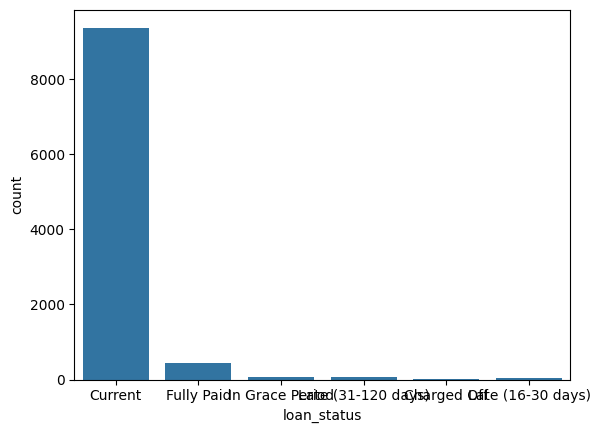

In [97]:
sns.countplot(x='loan_status',data=data)

In [98]:
#since current loans are not closed yet, we will remove them from the dataset
data=data[data['loan_status']!='Current']

<Axes: xlabel='loan_status', ylabel='count'>

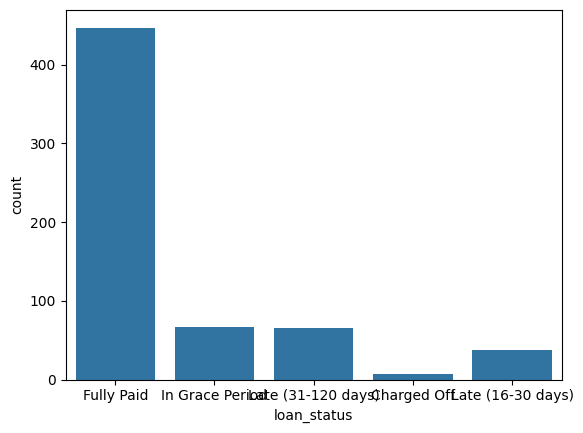

In [99]:
sns.countplot(x='loan_status',data=data)

In [100]:
data['loan_status'].value_counts()

loan_status
Fully Paid            447
In Grace Period        67
Late (31-120 days)     66
Late (16-30 days)      38
Charged Off             7
Name: count, dtype: int64

In [101]:
#Converting in grace,late and charged off into default
data['loan_status']=data['loan_status'].replace({'In Grace Period':'default',
                                                 'Late (16-30 days)':'default',
                                               'Late (31-120 days)':'default',
                                               'Charged Off':'default',
                                               'Fully Paid':'paid'})
data['loan_status'].value_counts()

loan_status
paid       447
default    178
Name: count, dtype: int64

<Axes: >

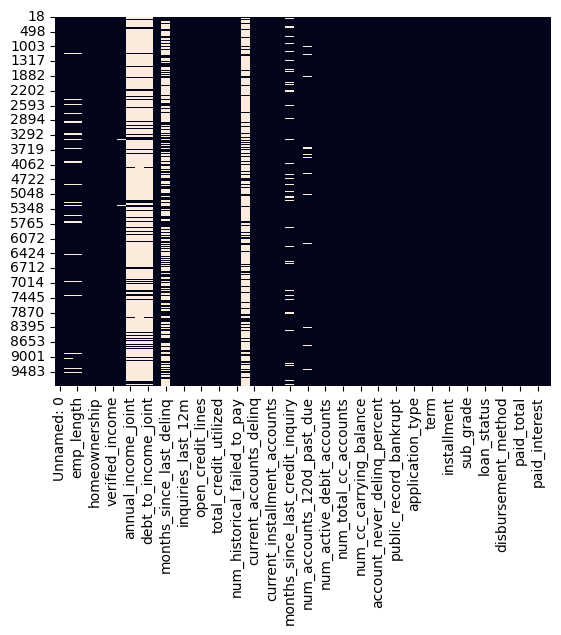

In [102]:
#checking missing values
sns.heatmap(data.isnull(),cbar=False)

In [103]:
data.isnull().sum()

Unnamed: 0                            0
emp_title                            43
emp_length                           41
state                                 0
homeownership                         0
annual_income                         0
verified_income                       0
debt_to_income                        3
annual_income_joint                 529
verification_income_joint           532
debt_to_income_joint                529
delinq_2y                             0
months_since_last_delinq            348
earliest_credit_line                  0
inquiries_last_12m                    0
total_credit_lines                    0
open_credit_lines                     0
total_credit_limit                    0
total_credit_utilized                 0
num_collections_last_12m              0
num_historical_failed_to_pay          0
months_since_90d_late               483
current_accounts_delinq               0
total_collection_amount_ever          0
current_installment_accounts          0


In [104]:
#dropping columns with more than 60% missing values
data.drop(['Unnamed: 0','annual_income_joint','verification_income_joint','debt_to_income_joint','months_since_last_delinq','months_since_90d_late'],axis=1,inplace=True)
data.isnull().sum()

emp_title                           43
emp_length                          41
state                                0
homeownership                        0
annual_income                        0
verified_income                      0
debt_to_income                       3
delinq_2y                            0
earliest_credit_line                 0
inquiries_last_12m                   0
total_credit_lines                   0
open_credit_lines                    0
total_credit_limit                   0
total_credit_utilized                0
num_collections_last_12m             0
num_historical_failed_to_pay         0
current_accounts_delinq              0
total_collection_amount_ever         0
current_installment_accounts         0
accounts_opened_24m                  0
months_since_last_credit_inquiry    57
num_satisfactory_accounts            0
num_accounts_120d_past_due          29
num_accounts_30d_past_due            0
num_active_debit_accounts            0
total_debit_limit        

In [105]:
#check head again
data.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,delinq_2y,earliest_credit_line,inquiries_last_12m,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
18,operational risk manager,10.0,IL,MORTGAGE,210000.0,Verified,9.53,0,2003,2,...,E5,Feb-2018,paid,fractional,Cash,0.00,5202.642672,5000.00,202.64,0.0
19,welder,1.0,CA,MORTGAGE,83000.0,Source Verified,18.44,3,2005,1,...,C4,Jan-2018,paid,whole,Cash,0.00,20653.717722,20000.00,653.72,0.0
34,deputy,10.0,CA,MORTGAGE,140000.0,Not Verified,13.82,0,1993,2,...,B2,Jan-2018,paid,whole,Cash,0.00,15005.166875,15000.00,5.17,0.0
35,armed protection officer,1.0,MD,OWN,70000.0,Source Verified,0.00,0,2004,0,...,A2,Jan-2018,paid,whole,Cash,0.00,2409.049993,2400.00,9.05,0.0
37,supplies clerk,10.0,NJ,MORTGAGE,70000.0,Verified,17.06,0,1988,2,...,C4,Mar-2018,default,whole,Cash,23455.27,1102.830000,544.73,558.10,0.0


In [106]:
#drop columns which leak information about the target variable
data.drop(['balance','paid_total','paid_principal','paid_interest','paid_late_fees','total_credit_utilized','current_accounts_delinq','num_accounts_30d_past_due','num_accounts_120d_past_due','num_collections_last_12m','total_collection_amount_ever'],axis=1,inplace=True)

In [107]:
data.drop(['emp_title'],axis=1,inplace=True)

In [108]:
data.isnull().sum()

emp_length                          41
state                                0
homeownership                        0
annual_income                        0
verified_income                      0
debt_to_income                       3
delinq_2y                            0
earliest_credit_line                 0
inquiries_last_12m                   0
total_credit_lines                   0
open_credit_lines                    0
total_credit_limit                   0
num_historical_failed_to_pay         0
current_installment_accounts         0
accounts_opened_24m                  0
months_since_last_credit_inquiry    57
num_satisfactory_accounts            0
num_active_debit_accounts            0
total_debit_limit                    0
num_total_cc_accounts                0
num_open_cc_accounts                 0
num_cc_carrying_balance              0
num_mort_accounts                    0
account_never_delinq_percent         0
tax_liens                            0
public_record_bankrupt   

In [109]:
#handle missing values
data['emp_length']=data['emp_length'].fillna(data['emp_length'].median())
data['debt_to_income']=data['debt_to_income'].fillna(data['debt_to_income'].median())

In [110]:
data['months_since_last_credit_inquiry'].value_counts()

months_since_last_credit_inquiry
0.0     59
2.0     56
1.0     56
4.0     48
3.0     44
7.0     41
5.0     39
8.0     36
6.0     31
9.0     26
11.0    23
10.0    21
12.0    13
13.0    12
15.0    11
16.0    11
17.0     8
14.0     7
18.0     5
20.0     5
21.0     5
22.0     5
19.0     2
23.0     2
24.0     2
Name: count, dtype: int64

In [111]:
#Months since last credit inquiry may be missing because they never had a credit inquiry or had it a long time ago
data['msci_missing'] = data['months_since_last_credit_inquiry'].isnull().astype(int)
data['months_since_last_credit_inquiry'] = data['months_since_last_credit_inquiry'].fillna(36)

In [112]:
data.isnull().sum()

emp_length                          0
state                               0
homeownership                       0
annual_income                       0
verified_income                     0
debt_to_income                      0
delinq_2y                           0
earliest_credit_line                0
inquiries_last_12m                  0
total_credit_lines                  0
open_credit_lines                   0
total_credit_limit                  0
num_historical_failed_to_pay        0
current_installment_accounts        0
accounts_opened_24m                 0
months_since_last_credit_inquiry    0
num_satisfactory_accounts           0
num_active_debit_accounts           0
total_debit_limit                   0
num_total_cc_accounts               0
num_open_cc_accounts                0
num_cc_carrying_balance             0
num_mort_accounts                   0
account_never_delinq_percent        0
tax_liens                           0
public_record_bankrupt              0
loan_purpose

<Axes: xlabel='loan_status', ylabel='debt_to_income'>

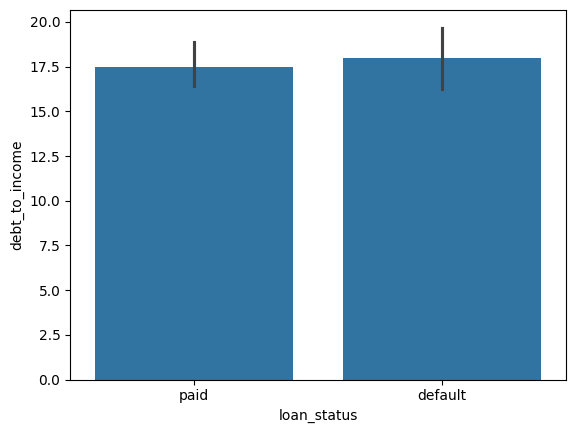

In [113]:
sns.barplot(x='loan_status',y='debt_to_income',data=data)

<Axes: xlabel='loan_status', ylabel='count'>

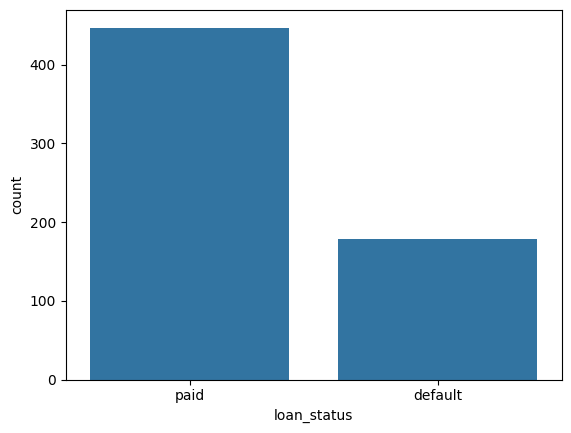

In [114]:
sns.countplot(x='loan_status',data=data)
#taret is imbalanced

In [115]:
#convert target variable into numerical
data['Loan_default']=data['loan_status'].map({'paid':0,'default':1})
data.drop('loan_status',axis=1,inplace=True)

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 625 entries, 18 to 9984
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_length                        625 non-null    float64
 1   state                             625 non-null    object 
 2   homeownership                     625 non-null    object 
 3   annual_income                     625 non-null    float64
 4   verified_income                   625 non-null    object 
 5   debt_to_income                    625 non-null    float64
 6   delinq_2y                         625 non-null    int64  
 7   earliest_credit_line              625 non-null    int64  
 8   inquiries_last_12m                625 non-null    int64  
 9   total_credit_lines                625 non-null    int64  
 10  open_credit_lines                 625 non-null    int64  
 11  total_credit_limit                625 non-null    int64  
 12  num_histori

In [117]:
data['grade'].value_counts()

grade
C    186
B    141
D    123
A    118
E     44
F     11
G      2
Name: count, dtype: int64

In [118]:
data['sub_grade'].value_counts()

sub_grade
C4    44
C2    41
B5    40
A4    37
C5    35
C3    34
C1    32
D3    31
B2    28
D1    27
B1    27
A5    27
D5    26
B4    23
B3    23
A3    23
D2    21
E5    19
A2    19
D4    18
A1    12
E3    11
E4     7
E2     5
F1     4
F3     3
F5     2
E1     2
G4     1
G1     1
F2     1
F4     1
Name: count, dtype: int64

In [119]:
#drop grade column since sub_grade has more detailed information
data.drop("grade",axis=1,inplace=True)

In [120]:
data['earliest_credit_line'].head()

18    2003
19    2005
34    1993
35    2004
37    1988
Name: earliest_credit_line, dtype: int64

In [121]:
data['credit_history_years'] = 2026 - data['earliest_credit_line']
data.drop('earliest_credit_line', axis=1, inplace=True)

In [122]:
final_cols=data.columns.tolist()
final_cols.remove('Loan_default')
final_cols.remove('msci_missing')

In [123]:
cat_columns=data.select_dtypes(include='object').columns
num_columns=[col for col in data.columns if col not in cat_columns]
num_columns.remove('Loan_default')

In [124]:
x= data.drop('Loan_default',axis=1)
y= data['Loan_default']

In [125]:
#import ml libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [126]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [127]:
#create column transformer for lr
ColTransformer_lr= ColumnTransformer(transformers=[
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_columns),
    ('num',StandardScaler(),num_columns)
])

#create column transformer for rf
ColTransformer_rf= ColumnTransformer(transformers=[
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_columns),
],remainder='passthrough')

In [128]:
#create pipeline for logistic regression
lrpipeline= Pipeline(steps=[
    ('preprocessor',ColTransformer_lr),
    ('classifier',LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42))
])

In [129]:
#create pipeline for logistic regression(l1 penalty and liblinear solver)
lr1pipeline= Pipeline(steps=[
    ('preprocessor',ColTransformer_lr),
    ('classifier',LogisticRegression(class_weight='balanced',max_iter=1000,solver='liblinear',penalty='l1',random_state=42)),
])

In [130]:
#create pipeline for random forest
rfpipeline= Pipeline(steps=[
    ('preprocessor',ColTransformer_rf),
    ('classifier',RandomForestClassifier(class_weight='balanced',random_state=42))
])

In [131]:
# hyperparameter tuning
lr_hyperparameters={
    'classifier__C':[0.01,0.1,1,10]
}

rf_hyperparameters = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_leaf': [5, 10]
}

In [132]:
#linear regression model
lrgrid= GridSearchCV(lrpipeline,lr_hyperparameters,cv=5,n_jobs=-1,verbose=3,scoring='roc_auc')
lrgrid.fit(x_train,y_train)
print(lrgrid.best_params_)
proba_lr = lrgrid.predict_proba(x_test)[:, 1]
pred_lr=(proba_lr > 0.5).astype(int)
print("Logistic Regression Classification Report:")
print(classification_report(y_test,pred_lr))
print(confusion_matrix(y_test,pred_lr))
print('roc_auc_score:', roc_auc_score(y_test, proba_lr))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'classifier__C': 0.1}
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.57      0.68        89
           1       0.40      0.69      0.51        36

    accuracy                           0.61       125
   macro avg       0.61      0.63      0.59       125
weighted avg       0.70      0.61      0.63       125

[[51 38]
 [11 25]]
roc_auc_score: 0.6544943820224719


In [133]:
#linear regression model(l1 penalty and liblinear solver)
lr1grid= GridSearchCV(lr1pipeline,lr_hyperparameters,cv=5,n_jobs=-1,verbose=3,scoring='roc_auc')
lr1grid.fit(x_train,y_train)
print(lr1grid.best_params_)
proba_lr1 = lr1grid.predict_proba(x_test)[:, 1]
pred_lr1=(proba_lr1 > 0.5).astype(int)
print("Logistic Regression Classification Report:")
print(classification_report(y_test,pred_lr1))
print(confusion_matrix(y_test,pred_lr1))
print('roc_auc_score:', roc_auc_score(y_test, proba_lr1))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'classifier__C': 1}
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.57      0.68        89
           1       0.40      0.69      0.51        36

    accuracy                           0.61       125
   macro avg       0.61      0.63      0.59       125
weighted avg       0.70      0.61      0.63       125

[[51 38]
 [11 25]]
roc_auc_score: 0.6679151061173534


In [134]:
#random forest model
rfgrid= GridSearchCV(rfpipeline,rf_hyperparameters,cv=5,n_jobs=-1,verbose=3,scoring='roc_auc')
rfgrid.fit(x_train,y_train)
print(rfgrid.best_params_)
proba_rf = rfgrid.predict_proba(x_test)[:, 1]
pred_rf=(proba_rf > 0.5).astype(int)
print("Random Forest Classification Report:")
print(classification_report(y_test,pred_rf))
print(confusion_matrix(y_test,pred_rf))
print('roc_auc_score:', roc_auc_score(y_test, proba_rf))

Fitting 5 folds for each of 8 candidates, totalling 40 fits


{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.82        89
           1       0.55      0.33      0.41        36

    accuracy                           0.73       125
   macro avg       0.66      0.61      0.62       125
weighted avg       0.70      0.73      0.71       125

[[79 10]
 [24 12]]
roc_auc_score: 0.6610486891385767


In [135]:
# FINAL MODEL SELECTED:
# L1-regularized Logistic Regression (liblinear)
# Chosen for higher ROC-AUC and better generalization

In [136]:
#to find optimal threshold
#lets assume cost of FN is 3 times the cost of FP because missing a defaulter is more costly than misclassifying a non-defaulter
cost_FN = 3
cost_FP = 1
cost = []
thresholds = np.arange(0.0, 1.0, 0.01)
for t in thresholds:
    pred=(proba_lr1 > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total_cost = (fn * cost_FN) + (fp * cost_FP)
    cost.append(total_cost)
optimal_threshold = thresholds[np.argmin(cost)]
print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.45


In [137]:
# #now we will train on whole data and save the model
import joblib
lr1=lr1grid.best_estimator_
lr1.fit(x,y)
joblib.dump(lr1,'../app/credit_risk_model.pkl')

['../app/credit_risk_model.pkl']